# Project 1 – Stack Overflow Developer Survey Analysis

## Introduction

In this project, I analyze data from the Stack Overflow Developer Survey.
The goal is to explore the dataset and build a simple machine learning model
to predict an outcome related to developers' careers based on survey responses.


# Section 1: Business Understanding (CRISP-DM)

## Objective
Explore which factors relate to yearly developer compensation and build a simple baseline model.

## Business Questions
**Q1)** Does work experience influence yearly compensation?  
**Q2)** Is job satisfaction related to compensation?  
**Q3)** Can a simple model predict compensation using these variables?

## Hypotheses (to test)
- **H1:** More work experience is associated with higher compensation.
- **H2:** Higher job satisfaction is associated with higher compensation.
- **H3:** A simple linear model explains some variance in compensation, but not most of it.


In [116]:
from typing import Tuple, Dict, List

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Section 2: Data Understanding (CRISP-DM)

We load the dataset and inspect basic structure (shape, dtypes) and summary statistics for the selected columns.

In [117]:
def load_dataset(csv_path: str) -> pd.DataFrame:
    """
    Load the Stack Overflow survey dataset from a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV dataset.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.
    """
    return pd.read_csv(csv_path)


def select_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Select a subset of columns for analysis/modeling.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    columns : list
        List of column names to select.

    Returns
    -------
    pd.DataFrame
        Subset dataframe with selected columns.
    """
    return df[columns].copy()


def handle_missing_values(df: pd.DataFrame, strategy: str = "drop") -> pd.DataFrame:
    """
    Handle missing values in the modeling dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe potentially containing missing values.
    strategy : str, default="drop"
        Strategy to handle missing values. Currently supports:
        - "drop": drop rows with any missing values

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe.
    """
    if strategy == "drop":
        return df.dropna()
    raise ValueError("Unsupported strategy. Use strategy='drop'.")


def compute_correlation(df: pd.DataFrame, x_col: str, y_col: str) -> float:
    """
    Compute Pearson correlation between two numeric columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    x_col : str
        Feature column name.
    y_col : str
        Target column name.

    Returns
    -------
    float
        Pearson correlation coefficient.
    """
    return float(df[[x_col, y_col]].corr().iloc[0, 1])


def split_features_target(
    df: pd.DataFrame, feature_cols: list, target_col: str, test_size: float = 0.2, random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Split data into train/test sets.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    feature_cols : list
        Feature columns.
    target_col : str
        Target column.
    test_size : float, default=0.2
        Proportion for test split.
    random_state : int, default=42
        Random seed.

    Returns
    -------
    X_train, X_test, y_train, y_test
    """
    X = df[feature_cols]
    y = df[target_col]
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def train_linear_regression(X_train: pd.DataFrame, y_train: pd.Series) -> LinearRegression:
    """
    Train a Linear Regression model.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training target.

    Returns
    -------
    LinearRegression
        Trained model.
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def evaluate_regression(model: LinearRegression, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, float]:
    """
    Evaluate regression model using MSE and R2.

    Parameters
    ----------
    model : LinearRegression
        Trained model.
    X_test : pd.DataFrame
        Test features.
    y_test : pd.Series
        Test target.

    Returns
    -------
    dict
        Dictionary with 'mse' and 'r2' scores.
    """
    preds = model.predict(X_test)
    return {
        "mse": float(mean_squared_error(y_test, preds)),
        "r2": float(r2_score(y_test, preds)),
    }

In [ ]:
# Configuración
CSV_PATH = "data/survey_results_public.csv"

COLUMNS_OF_INTEREST = ["WorkExp", "YearsCode", "JobSat", "ConvertedCompYearly"]
FEATURE_COLS = ["WorkExp", "YearsCode", "JobSat"]
TARGET_COL = "ConvertedCompYearly"

# 1) Load
df = load_dataset(CSV_PATH)

# 2) Subset
model_df = select_columns(df, COLUMNS_OF_INTEREST)


df.shape, model_df.shape, model_df.dtypes
model_df.describe()








C:\Users\julian.monte\AppData\Local\Temp\ipykernel_30420\2910571060.py:15: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_path)



# Section 3: Data Preparation (CRISP-DM)

This section covers cleaning steps required for modeling, especially missing values analysis and handling.




In [ ]:
# Missing values analysis (before cleaning)
missing_counts = model_df.isna().sum().sort_values(ascending=False)
missing_pct = (model_df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

missing_report

# Impact of dropping missing values (complete-case analysis)
rows_before = model_df.shape[0]
rows_after_drop = model_df.dropna().shape[0]
dropped_rows = rows_before - rows_after_drop
dropped_pct = (dropped_rows / rows_before) * 100

rows_before, rows_after_drop, dropped_rows, dropped_pct


(19213, 19213, 0, 0.0)

### Missing values handling decision (justification)

We report missingness per column and the percentage of rows removed above.
For this baseline project, we drop rows with missing values because:

- The goal is a simple, reproducible baseline workflow.
- The fraction of removed rows is explicitly measured (see output above).
- Imputing survey-based scores without stronger assumptions can introduce artificial patterns.

**Note:** Dropping rows can bias results if missingness is systematic. For transparency, we document missingness rates and how many rows are removed.

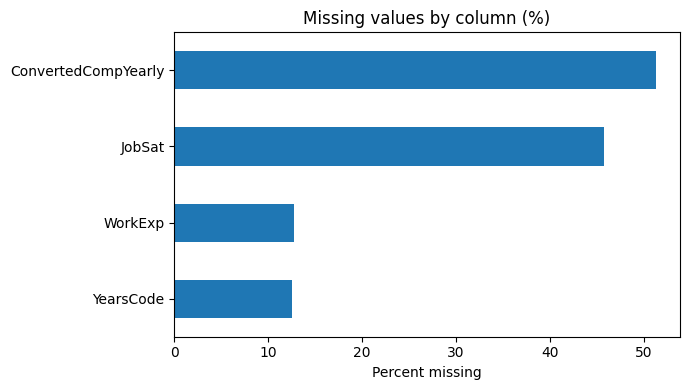

In [121]:

# Visual: missingness percentage by column
Path("img").mkdir(exist_ok=True)

plt.figure(figsize=(7,4))
missing_pct.sort_values(ascending=True).plot(kind="barh")
plt.title("Missing values by column (%)")
plt.xlabel("Percent missing")
plt.tight_layout()
plt.savefig("img/missing_values_pct.png", dpi=200)
plt.show()


In [122]:
model_df = handle_missing_values(model_df, strategy="drop")


# Section 4: Modeling (CRISP-DM)

We train a Linear Regression model as a simple, interpretable baseline to estimate yearly compensation.


In [123]:
X_train, X_test, y_train, y_test = split_features_target(
    model_df, FEATURE_COLS, TARGET_COL, test_size=0.2, random_state=42
)

model = train_linear_regression(X_train, y_train)

metrics = evaluate_regression(model, X_test, y_test)
metrics

{'mse': 85905499146.99739, 'r2': 0.005676464523364899}

# Section 5: Evaluation (CRISP-DM)

Below we answer each business question with a statistic and a visualization, plus a short interpretation.

In [124]:
q1_corr = compute_correlation(model_df, "WorkExp", "ConvertedCompYearly")
q2_corr = compute_correlation(model_df, "JobSat", "ConvertedCompYearly")

q1_corr, q2_corr

(0.08122298404226666, 0.022902425721514613)

### Quick insights
- **Q1:** The correlation and scatter plot suggest how compensation changes with work experience (trend + variability).
- **Q2:** The correlation indicates whether higher job satisfaction tends to align with higher compensation (relationship strength may be small).


In [125]:
Path("img").mkdir(exist_ok=True)
Path("img").resolve() 

WindowsPath('C:/Users/julian.monte/Documents/data-science/project1/img')

In [126]:


def plot_workexp_vs_comp(df: pd.DataFrame, x_col: str, y_col: str, out_path: str) -> Path:
    """
    Plot and save a scatter chart to visualize relationship between a feature and the target.
    Creates the output directory if it does not exist.

    Returns
    -------
    Path
        The absolute path where the plot was saved.
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)  # crea img/ si no existe

    plt.figure(figsize=(7, 4))
    plt.scatter(df[x_col], df[y_col], alpha=0.3)
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

    return out_path.resolve()


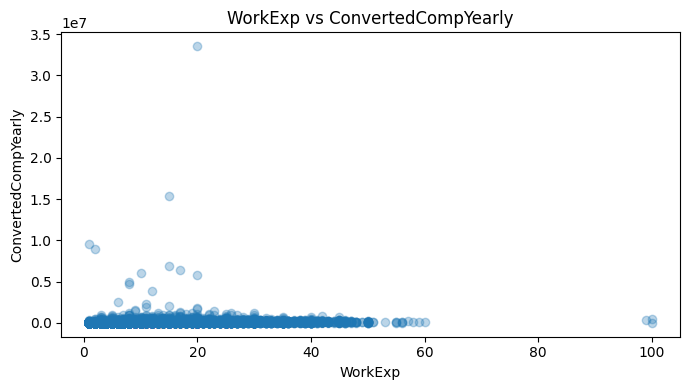

WindowsPath('C:/Users/julian.monte/Documents/data-science/project1/img/workexp_vs_comp.png')

In [127]:
saved_path = plot_workexp_vs_comp(model_df, "WorkExp", "ConvertedCompYearly", "img/workexp_vs_comp.png")
saved_path

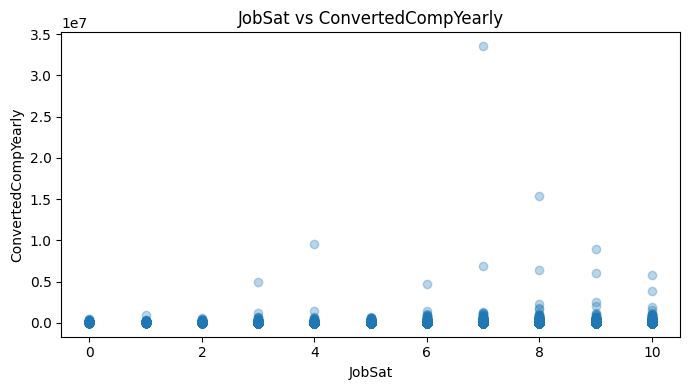

In [128]:
# Q2 visualization: JobSat vs Compensation
plt.figure(figsize=(7, 4))
plt.scatter(model_df["JobSat"], model_df["ConvertedCompYearly"], alpha=0.3)
plt.title("JobSat vs ConvertedCompYearly")
plt.xlabel("JobSat")
plt.ylabel("ConvertedCompYearly")
plt.tight_layout()
plt.savefig("img/jobsat_vs_comp.png", dpi=200)
plt.show()



### Q2 Interpretation
This plot helps visualize whether higher job satisfaction tends to align with higher compensation. The relationship may be weak or noisy, which suggests satisfaction alone is not a strong salary signal.


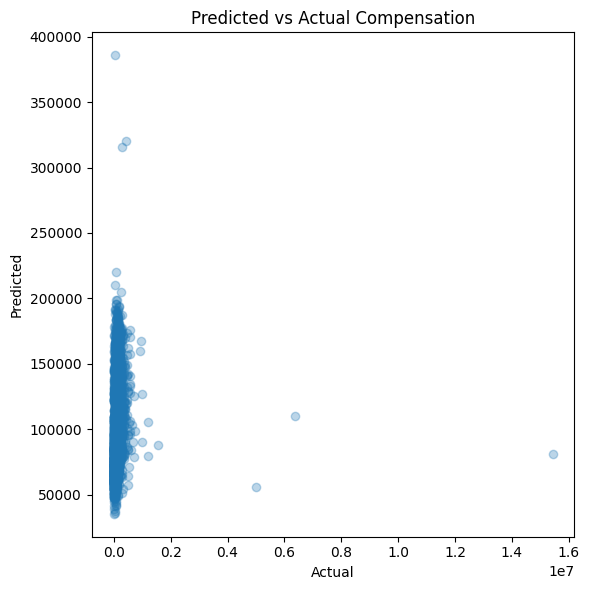

In [129]:
# Q3 visualization: Predicted vs Actual
preds = model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.title("Predicted vs Actual Compensation")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig("img/pred_vs_actual.png", dpi=200)
plt.show()


### Q3 Interpretation
If predictions were perfect, points would lie close to a diagonal line. Large dispersion indicates the model explains only part of the variation, meaning important drivers (e.g., location, role, company) are missing.


In [130]:
def predict_compensation(model: LinearRegression, work_exp: float, years_code: float, job_sat: float) -> float:
    """
    Predict yearly compensation for a hypothetical developer profile.

    Parameters
    ----------
    model : LinearRegression
        Trained model.
    work_exp : float
        Work experience in years.
    years_code : float
        Years of coding.
    job_sat : float
        Job satisfaction score.

    Returns
    -------
    float
        Predicted yearly compensation.
    """
    example = pd.DataFrame({
        "WorkExp": [work_exp],
        "YearsCode": [years_code],
        "JobSat": [job_sat]
    })
    return float(model.predict(example)[0])


In [131]:
predicted_salary = predict_compensation(model, work_exp=10, years_code=8, job_sat=7)
predicted_salary

68644.21522004143